# Understanding the problem space

El objetivo de este documento es realizar la primera tarea del módulo 2, Understanding the problem space.

Voy a repartir el análisis en las siguientes partes:

1. Cargar los datos extraidos a través de AWS CLI. Los he guardado en un directorio dentro de mi WSL llamado `data` 
2. Hacer un `head()` y un `describe()` de los 5 datasets.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Cargo los datos

In [3]:
df_users = pd.read_parquet('~/data/users.parquet', engine='pyarrow')
df_orders = pd.read_parquet('~/data/orders.parquet', engine='pyarrow')
df_abandoned_carts = pd.read_parquet('~/data/abandoned_carts.parquet', engine='pyarrow')
df_inventory = pd.read_parquet('~/data/inventory.parquet', engine='pyarrow')
df_regulars = pd.read_parquet('~/data/regulars.parquet', engine='pyarrow')

In [4]:
def df_info_head_describe(df):
    df.info()
    display(df.head())
    display(df.describe())

## Users

In [5]:
df_info_head_describe(df_users)

<class 'pandas.core.frame.DataFrame'>
Index: 4983 entries, 2160 to 3360
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                4983 non-null   object 
 1   user_segment           4983 non-null   object 
 2   user_nuts1             4932 non-null   object 
 3   first_ordered_at       4983 non-null   object 
 4   customer_cohort_month  4983 non-null   object 
 5   count_people           325 non-null    float64
 6   count_adults           325 non-null    float64
 7   count_children         325 non-null    float64
 8   count_babies           325 non-null    float64
 9   count_pets             325 non-null    float64
dtypes: float64(5), object(5)
memory usage: 428.2+ KB


,user_id,user_segment,user_nuts1,first_ordered_at,customer_cohort_month,count_people,count_adults,count_children,count_babies,count_pets
2160,0e823a42e107461379e5b5613b7aa00537a72e1b0eaa7a...,Top Up,UKH,2021-05-08 13:33:49,2021-05-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1123,15768ced9bed648f745a7aa566a8895f7a73b9a47c1d4f...,Top Up,UKJ,2021-11-17 16:30:20,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1958,33e0cb6eacea0775e34adbaa2c1dec16b9d6484e6b9324...,Top Up,UKD,2022-03-09 23:12:25,2022-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN
675,57ca7591dc79825df0cecc4836a58e6062454555c86c35...,Top Up,UKI,2021-04-23 16:29:02,2021-04-01 00:00:00,NaN,NaN,NaN,NaN,NaN
4694,085d8e598139ce6fc9f75d9de97960fa9e1457b409ec00...,Top Up,UKJ,2021-11-02 13:50:06,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN


,count_people,count_adults,count_children,count_babies,count_pets
count,325.000000,325.000000,325.000000,325.000000,325.000000
mean,2.787692,2.003077,0.707692,0.076923,0.636923
std,1.365753,0.869577,1.026246,0.289086,0.995603
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,0.000000,0.000000,0.000000
50%,3.000000,2.000000,0.000000,0.000000,0.000000
75%,4.000000,2.000000,1.000000,0.000000,1.000000
max,8.000000,7.000000,6.000000,2.000000,6.000000


Tenemos las siguientes columnas:

- `user_id`: Identificador del usuario
    - Hay clientes duplicados?
- `user_segment`: Variable categórica con baja cardinalidad: Top Up o Proposition
    - Que representa cada una de las cosas?
    - Este dato esta relacionado con la fecha en la que aparece el cliente? De que depende?
    - Creo que va a depender de si el cliente realiza muchas compras o no. Cómo puedo hacer esto?
- `user_nuts1`: Localización del cliente. Está indicado por la región nuts1. En este link más info https://en.wikipedia.org/wiki/First-level_NUTS_of_the_European_Union
- `first_ordered_at`: 
- `customer_cohort_month`:

Solo tiene tenemos datos del 6.52% de los clientes para estas variables:
- `count_people`
- `count_adults`
- `count_children`
- `count_babies`
- `count_pets`

¿Porque tenemos pocas entradas de estas variables?
- Tal vez los datos se proporcionan de manera voluntaria
- Tal vez los datos se empezaron a recoger para una fecha concreta: En este caso, las entradas deberían estar a partir de una fecha concreta.


¿Cómo ha evolucionado el número de clientes a lo largo del tiempo?
De es

Segmentación de clientes? Puede venir bien para entender los tipos de customers que puede haber.

In [6]:
df_users.groupby('user_segment').user_id.nunique()

user_segment
Proposition    2340
Top Up         2643
Name: user_id, dtype: int64

In [7]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4983 entries, 2160 to 3360
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                4983 non-null   object 
 1   user_segment           4983 non-null   object 
 2   user_nuts1             4932 non-null   object 
 3   first_ordered_at       4983 non-null   object 
 4   customer_cohort_month  4983 non-null   object 
 5   count_people           325 non-null    float64
 6   count_adults           325 non-null    float64
 7   count_children         325 non-null    float64
 8   count_babies           325 non-null    float64
 9   count_pets             325 non-null    float64
dtypes: float64(5), object(5)
memory usage: 428.2+ KB


## Orders

In [8]:
df_info_head_describe(df_orders)

<class 'pandas.core.frame.DataFrame'>
Index: 8773 entries, 10 to 64538
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              8773 non-null   int64         
 1   user_id         8773 non-null   object        
 2   created_at      8773 non-null   datetime64[us]
 3   order_date      8773 non-null   datetime64[us]
 4   user_order_seq  8773 non-null   int64         
 5   ordered_items   8773 non-null   object        
dtypes: datetime64[us](2), int64(2), object(2)
memory usage: 479.8+ KB


,id,user_id,created_at,order_date,user_order_seq,ordered_items
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,"[33618849693828, 33618860179588, 3361887404045..."
20,2204707520644,bf591c887c46d5d3513142b6a855dd7ffb9cc00697f6f5...,2020-04-30 17:39:00,2020-04-30,1,"[33618835243140, 33618835964036, 3361886244058..."
21,2204838822020,329f08c66abb51f8c0b8a9526670da2d94c0c6eef06700...,2020-04-30 18:12:30,2020-04-30,1,"[33618891145348, 33618893570180, 3361889766618..."
34,2208967852164,f6451fce7b1c58d0effbe37fcb4e67b718193562766470...,2020-05-01 19:44:11,2020-05-01,1,"[33618830196868, 33618846580868, 3361891234624..."
49,2215889436804,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,2020-05-03 21:56:14,2020-05-03,1,"[33667166699652, 33667166699652, 3366717122163..."


,id,created_at,order_date,user_order_seq
count,8.773000e+03,8773,8773,8773.000000
mean,3.684684e+12,2021-08-22 03:54:18.750028,2021-08-21 12:47:21.262966,2.445116
min,2.204073e+12,2020-04-30 14:32:19,2020-04-30 00:00:00,1.000000
25%,3.690255e+12,2021-04-25 11:50:37,2021-04-25 00:00:00,1.000000
50%,3.846692e+12,2021-10-11 11:29:44,2021-10-11 00:00:00,1.000000
75%,3.945086e+12,2022-01-03 18:14:23,2022-01-03 00:00:00,3.000000
max,4.026732e+12,2022-03-14 00:24:59,2022-03-14 00:00:00,25.000000
std,4.145437e+11,NaN,NaN,2.707693


Variables:
- id: Identificador único de la orden (compra)
- user_id: usuario que ha realizado la compra. ¿Siempre tenemos a los usuarios identificados?
- created_at: Fecha y hora de la creación de la orden. ¿Como han evolucionado a lo largo del tiempo? ¿cuantas compras hace cada cliente? ¿se hacen compras periódicas?
- order_date: Día de creación de la orden
- user_order_seq: "user order sequence". Corresponde al número de orden de cada cliente.
- ordered_items: Lista de cada uno de los items comprados.

## Inventory

In [9]:
df_info_head_describe(df_inventory)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1733 entries, 0 to 1732
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   variant_id        1733 non-null   int64  
 1   price             1733 non-null   float64
 2   compare_at_price  1733 non-null   float64
 3   vendor            1733 non-null   object 
 4   product_type      1733 non-null   object 
 5   tags              1733 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 81.4+ KB


,variant_id,price,compare_at_price,vendor,product_type,tags
0,39587297165444,3.09,3.15,heinz,condiments-dressings,"[table-sauces, vegan]"
1,34370361229444,4.99,5.50,whogivesacrap,toilet-roll-kitchen-roll-tissue,"[b-corp, eco, toilet-rolls]"
2,34284951863428,3.69,3.99,plenty,toilet-roll-kitchen-roll-tissue,[kitchen-roll]
3,33667283583108,1.79,1.99,thecheekypanda,toilet-roll-kitchen-roll-tissue,"[b-corp, cruelty-free, eco, tissue, vegan]"
4,33803537973380,1.99,2.09,colgate,dental,[dental-accessories]


,variant_id,price,compare_at_price
count,1.733000e+03,1733.000000,1733.000000
mean,3.694880e+13,6.307351,7.028881
std,2.725674e+12,7.107218,7.660542
min,3.361529e+13,0.000000,0.000000
25%,3.427657e+13,2.490000,2.850000
50%,3.927260e+13,3.990000,4.490000
75%,3.948318e+13,7.490000,8.210000
max,4.016793e+13,59.990000,60.000000


Algo muy interesante que se observa entre las variables `price` y `compare at price` es que por lo general el precio de la competencia es mayor que el precio de nuestra marca e-commerce.
Hay un posible error en los datos: ¿Producto con precio = 0€?
El producto más caro del supermercado vale 60€, ¿cuál es?

- variant_id:
- price
- compare_at_price
- vendor
- poduct_type
- tags

Hay 1733 productos. Todos los campos de estos productos están informados.
Como no se indican fechas en este dataset supongo que el inventario es el que hay

## Regulars

In [10]:
df_info_head_describe(df_regulars)

<class 'pandas.core.frame.DataFrame'>
Index: 18105 entries, 3 to 37720
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     18105 non-null  object        
 1   variant_id  18105 non-null  int64         
 2   created_at  18105 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), object(1)
memory usage: 565.8+ KB


,user_id,variant_id,created_at
3,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,33618848088196,2020-04-30 15:07:03
11,aed88fc0b004270a62ff1fe4b94141f6b1db1496dbb0c0...,33667178659972,2020-05-05 23:34:35
18,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,33619009208452,2020-04-30 15:07:03
46,aed88fc0b004270a62ff1fe4b94141f6b1db1496dbb0c0...,33667305373828,2020-05-05 23:34:35
47,4594e99557113d5a1c5b59bf31b8704aafe5c7bd180b32...,33667247341700,2020-05-06 14:42:11


,variant_id,created_at
count,1.810500e+04,18105
mean,3.511989e+13,2021-08-15 02:27:30.703728
min,3.361527e+13,2020-04-30 13:09:27
25%,3.382643e+13,2021-03-21 10:41:42
50%,3.422171e+13,2021-10-16 09:11:26
75%,3.448855e+13,2022-01-14 22:35:14
max,4.013362e+13,2022-03-14 07:49:24
std,2.171237e+12,NaN


## Abandoned Carts

In [11]:
df_info_head_describe(df_abandoned_carts)

<class 'pandas.core.frame.DataFrame'>
Index: 5457 entries, 0 to 70050
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          5457 non-null   int64         
 1   user_id     5457 non-null   object        
 2   created_at  5457 non-null   datetime64[us]
 3   variant_id  5457 non-null   object        
dtypes: datetime64[us](1), int64(1), object(2)
memory usage: 213.2+ KB


,id,user_id,created_at,variant_id
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,"[33826459287684, 33826457616516, 3366719212762..."
13,20352449839236,9d6187545c005d39e44d0456d87790db18611d7c7379bd...,2021-06-27 05:24:13,"[34415988179076, 34037940158596, 3450282236326..."
45,20478401413252,e83fb0273d70c37a2968fee107113698fd4f389c442c0b...,2021-07-18 08:23:49,"[34543001337988, 34037939372164, 3411360609088..."
50,20481783103620,10c42e10e530284b7c7c50f3a23a98726d5747b8128084...,2021-07-18 21:29:36,"[33667268116612, 34037940224132, 3443605520397..."
52,20485321687172,d9989439524b3f6fc4f41686d043f315fb408b954d6153...,2021-07-19 12:17:05,"[33667268083844, 34284950454404, 33973246886020]"


,id,created_at
count,5.457000e+03,5457
mean,2.161881e+13,2021-12-20 11:07:10.198460
min,1.285856e+13,2020-05-20 13:53:24
25%,2.133401e+13,2021-11-13 19:52:17
50%,2.167062e+13,2021-12-27 13:14:57
75%,2.192303e+13,2022-01-30 08:35:19
max,2.223385e+13,2022-03-13 14:12:10
std,4.028679e+11,NaN


# Objetivos del análisis

En la teoría hemos visto que la parte mas importante es: **¿Qué es lo que quiero saber de los datos?**

Por ser un e-commerce me parece muy interesante:
- Conocer los clientes: localizacion, edad, numero de compras, ...
- Conocer la evolución de las ventas
- Conocer los productos más vendidos
- Marcas más vendidas


Quiero conocer a mis proveedores mejor.

¿Que productos venden?
¿Cuántos productos venden?
¿Cuanto se venden sus productos?
¿Cuánto se factura por cada proveedor?
Evolución de la facturación debida a cada proveedor

In [12]:
df_inventory

,variant_id,price,compare_at_price,vendor,product_type,tags
0,39587297165444,3.09,3.15,heinz,condiments-dressings,"[table-sauces, vegan]"
1,34370361229444,4.99,5.50,whogivesacrap,toilet-roll-kitchen-roll-tissue,"[b-corp, eco, toilet-rolls]"
2,34284951863428,3.69,3.99,plenty,toilet-roll-kitchen-roll-tissue,[kitchen-roll]
3,33667283583108,1.79,1.99,thecheekypanda,toilet-roll-kitchen-roll-tissue,"[b-corp, cruelty-free, eco, tissue, vegan]"
4,33803537973380,1.99,2.09,colgate,dental,[dental-accessories]
...,...,...,...,...,...,...
1728,39539419218052,4.99,5.99,bother,,[household-sundries]
1729,34534187368580,4.69,5.49,tommeetippee,baby-accessories,[feeding-weaning]
1730,33826439594116,15.39,17.15,colief,baby-accessories,[feeding-weaning]
1731,33667214508164,19.49,21.65,enterosgel,medicines-treatments,"[discontinue, first-aid]"


In [13]:
print(df_inventory.shape)
print(df_inventory.groupby('vendor').variant_id.nunique())

(1733, 6)
vendor
7up             1
absolut         1
alpro           4
always          6
ambrosia        4
               ..
wilkinsons      1
williescacao    1
wingyip         3
yarrah          3
zoflora         3
Name: variant_id, Length: 412, dtype: int64


Vemos que hay 1.733 productos diferentes.

Encontramos también 412 proveedores distintos.

Esto quiere decir que en media cada proveedor nos da 1733/412 = 4.21 productos

In [14]:
vendors = df_inventory.groupby('vendor').variant_id.nunique().reset_index()


top_vendors = vendors.sort_values(by='variant_id', ascending=False).head(20)

In [15]:
top_vendors

,vendor,variant_id
43,biona,69
121,ecover,34
255,napolina,28
132,faithinnature,27
239,method,26
173,hiderfoods,24
161,greencuisine,24
381,various,23
124,ellaskitchen,18
93,cooksco,17


Se pueden estar colando proveedores con productos pequeños que no supongan una facturación importante de la empresa. Por eso, pasamos a obtener la facturación que hacen estos proveedores. La facturación puede ser histórica (para ver si ha habido una evolución destacable) o puede ser del último mes (para conocer nuestros proveedores mas relevantes y tratar de cuidar la relación con ellos)

In [16]:
df_orders

,id,user_id,created_at,order_date,user_order_seq,ordered_items
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,"[33618849693828, 33618860179588, 3361887404045..."
20,2204707520644,bf591c887c46d5d3513142b6a855dd7ffb9cc00697f6f5...,2020-04-30 17:39:00,2020-04-30,1,"[33618835243140, 33618835964036, 3361886244058..."
21,2204838822020,329f08c66abb51f8c0b8a9526670da2d94c0c6eef06700...,2020-04-30 18:12:30,2020-04-30,1,"[33618891145348, 33618893570180, 3361889766618..."
34,2208967852164,f6451fce7b1c58d0effbe37fcb4e67b718193562766470...,2020-05-01 19:44:11,2020-05-01,1,"[33618830196868, 33618846580868, 3361891234624..."
49,2215889436804,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,2020-05-03 21:56:14,2020-05-03,1,"[33667166699652, 33667166699652, 3366717122163..."
...,...,...,...,...,...,...
64396,4026096910468,f524eaf26b76bc6226747768f120ffcd23d5c3d52a0a19...,2022-03-13 10:14:22,2022-03-13,5,"[33981947707524, 34284951273604, 3428495127360..."
64488,4026464993412,aa5e21db3186dcd84c161719c5ade8a19adb853ea8bfef...,2022-03-13 18:30:31,2022-03-13,3,"[33803540725892, 34284950519940, 3437091504141..."
64499,4026553434244,14be3833c19e0a1fd7e6db0e5375a3d1dcc9efafcb0e69...,2022-03-13 20:11:50,2022-03-13,11,"[39283356663940, 39283356663940, 4015514504410..."
64523,4026656030852,500027bf392bfa9ef527919569fba44904d429155b7cf4...,2022-03-13 22:29:24,2022-03-13,4,"[33824368033924, 33824368033924, 3382436803392..."


In [17]:
df_exploded = df_orders.explode('ordered_items').rename(columns={"ordered_items":"variant_id"})
df_exploded

,id,user_id,created_at,order_date,user_order_seq,variant_id
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,33618849693828
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,33618860179588
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,33618874040452
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,33618907005060
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,33618907005060
...,...,...,...,...,...,...
64538,4026732413060,faaad4bc113fe7e0a888a0d3535877d3c692f591882c25...,2022-03-14 00:24:59,2022-03-14,3,34537169453188
64538,4026732413060,faaad4bc113fe7e0a888a0d3535877d3c692f591882c25...,2022-03-14 00:24:59,2022-03-14,3,39368665432196
64538,4026732413060,faaad4bc113fe7e0a888a0d3535877d3c692f591882c25...,2022-03-14 00:24:59,2022-03-14,3,39403033428100
64538,4026732413060,faaad4bc113fe7e0a888a0d3535877d3c692f591882c25...,2022-03-14 00:24:59,2022-03-14,3,39459281272964


In [18]:
df_inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1733 entries, 0 to 1732
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   variant_id        1733 non-null   int64  
 1   price             1733 non-null   float64
 2   compare_at_price  1733 non-null   float64
 3   vendor            1733 non-null   object 
 4   product_type      1733 non-null   object 
 5   tags              1733 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 81.4+ KB


In [19]:
df_orders_exploded = df_exploded.merge(df_inventory, on='variant_id', how='left')

In [20]:
df_orders_exploded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107958 entries, 0 to 107957
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                107958 non-null  int64         
 1   user_id           107958 non-null  object        
 2   created_at        107958 non-null  datetime64[us]
 3   order_date        107958 non-null  datetime64[us]
 4   user_order_seq    107958 non-null  int64         
 5   variant_id        107958 non-null  object        
 6   price             92361 non-null   float64       
 7   compare_at_price  92361 non-null   float64       
 8   vendor            92361 non-null   object        
 9   product_type      92361 non-null   object        
 10  tags              92361 non-null   object        
dtypes: datetime64[us](2), float64(2), int64(2), object(5)
memory usage: 9.1+ MB


Vemos que históricamente se han vendido 107.958 productos distintos.

También se puede ver que después del cruce no se han llenado todas las filas del df de ordenes. Como hemos hecho join por variant_id, esto quiere decir que df_inventory no tiene cada uno de los productos con los que estamos trabajando. 

¿Como de grande es el daño? 

¿Cuantos productos nos faltan? 

¿A que se puede deber?

In [21]:
107958 - 92361

15597

15.597 ventas no tienen producto en el inventario asociado (y por tanto desconocemos su precio)

In [24]:
n_productos_registrados = df_inventory.shape[0]

n_productos_no_registrados = df_orders_exploded[df_orders_exploded.price.isnull()].variant_id.nunique()

print(f"No tenemos registrados un {round(n_productos_no_registrados / (n_productos_no_registrados + n_productos_registrados) * 100, 2)}% de los productos vendidos")

No tenemos registrados un 26.97% de los productos vendidos


Hay 640 productos no identificados, lo que supone un 26.97% de de todos los productos que se han vendido. Esto supone un problema importante, ya que, entre otras cosas, no vamos a conocer el precio de venta y por tanto la facturación real.

**Hipótesis**

El inventario al que tenemos acceso es el inventario actual, el resto de productos están descatalogados. 

Para comprobar esta hipótesis podemos hacer una representación de 

In [51]:
df_orders_exploded['registrado'] = df_orders_exploded.apply(lambda row: 0 if row.isnull().any() else 1, axis=1)

In [52]:
df_orders_exploded.value_counts('registrado')

registrado
1    92361
0    15597
Name: count, dtype: int64

In [53]:
df_orders_exploded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107958 entries, 0 to 107957
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                107958 non-null  int64         
 1   user_id           107958 non-null  object        
 2   created_at        107958 non-null  datetime64[us]
 3   order_date        107958 non-null  datetime64[us]
 4   user_order_seq    107958 non-null  int64         
 5   variant_id        107958 non-null  object        
 6   price             92361 non-null   float64       
 7   compare_at_price  92361 non-null   float64       
 8   vendor            92361 non-null   object        
 9   product_type      92361 non-null   object        
 10  tags              92361 non-null   object        
 11  registrado        107958 non-null  int64         
dtypes: datetime64[us](2), float64(2), int64(3), object(5)
memory usage: 9.9+ MB


In [92]:
df_evolucion_producto_registrado = df_orders_exploded[['order_date','registrado']].pivot_table(index='order_date', columns='registrado', aggfunc='size', fill_value=0 )
df_evolucion_producto_registrado.columns = ['no_registrado', 'registrado']
df_evolucion_producto_registrado['ventas_diarias'] = df_evolucion_producto_registrado['no_registrado'] + df_evolucion_producto_registrado['registrado']
df_evolucion_producto_registrado
df_evolucion_producto_registrado['pct_no_registrado'] = df_evolucion_producto_registrado['no_registrado']/df_evolucion_producto_registrado['ventas_diarias']*100
df_evolucion_producto_registrado['pct_registrado'] = df_evolucion_producto_registrado['registrado']/df_evolucion_producto_registrado['ventas_diarias']*100

df_evolucion_producto_registrado

,no_registrado,registrado,ventas_diarias,pct_no_registrado,pct_registrado
order_date,,,,,
2020-04-30,54,0,54,100.000000,0.000000
2020-05-01,10,0,10,100.000000,0.000000
2020-05-03,8,2,10,80.000000,20.000000
2020-05-04,12,5,17,70.588235,29.411765
2020-05-05,8,3,11,72.727273,27.272727
...,...,...,...,...,...
2022-03-10,2,308,310,0.645161,99.354839
2022-03-11,6,357,363,1.652893,98.347107
2022-03-12,2,85,87,2.298851,97.701149


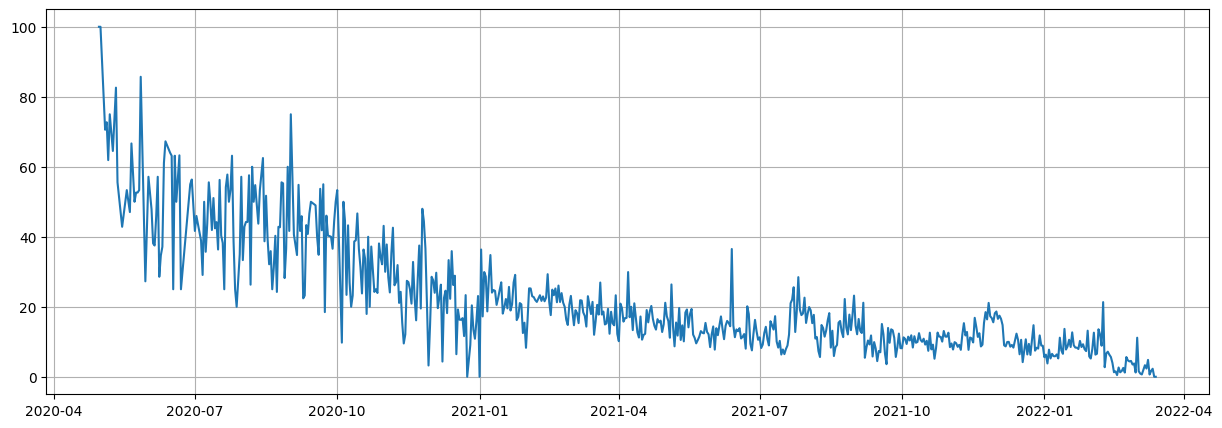

In [98]:
plt.figure(figsize=(15,5))
plt.plot(df_evolucion_producto_registrado.index,df_evolucion_producto_registrado.pct_no_registrado)
plt.grid()

Por la forma del gráfico parece

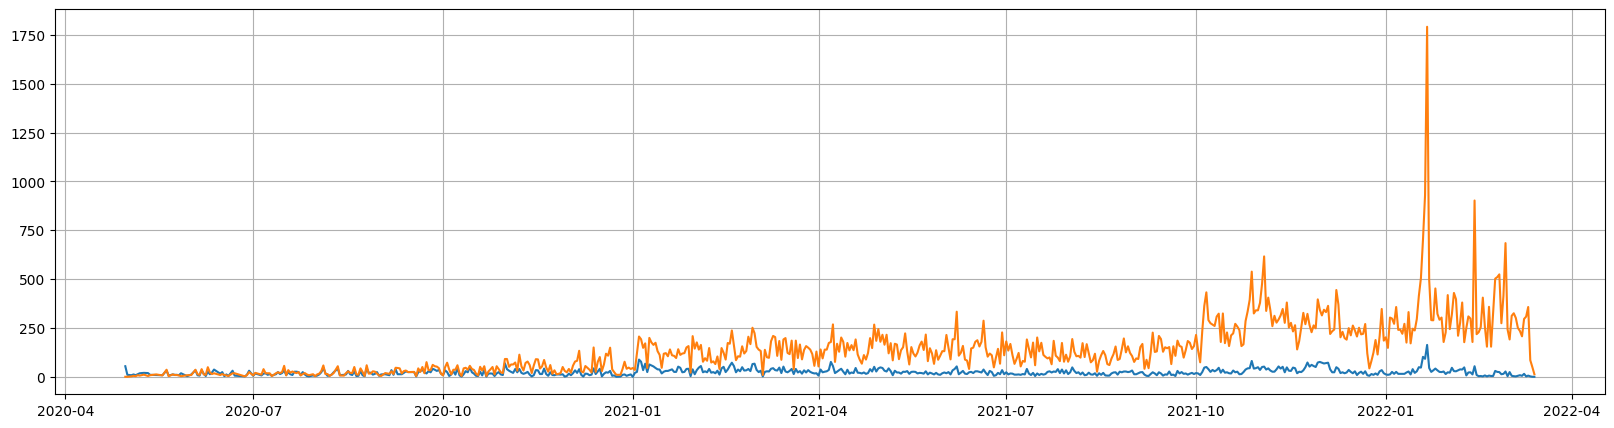

In [87]:
plt.subplots(figsize=(20,5))
plt.plot(df_evolucion_producto_registrado)
plt.grid(visible=True)

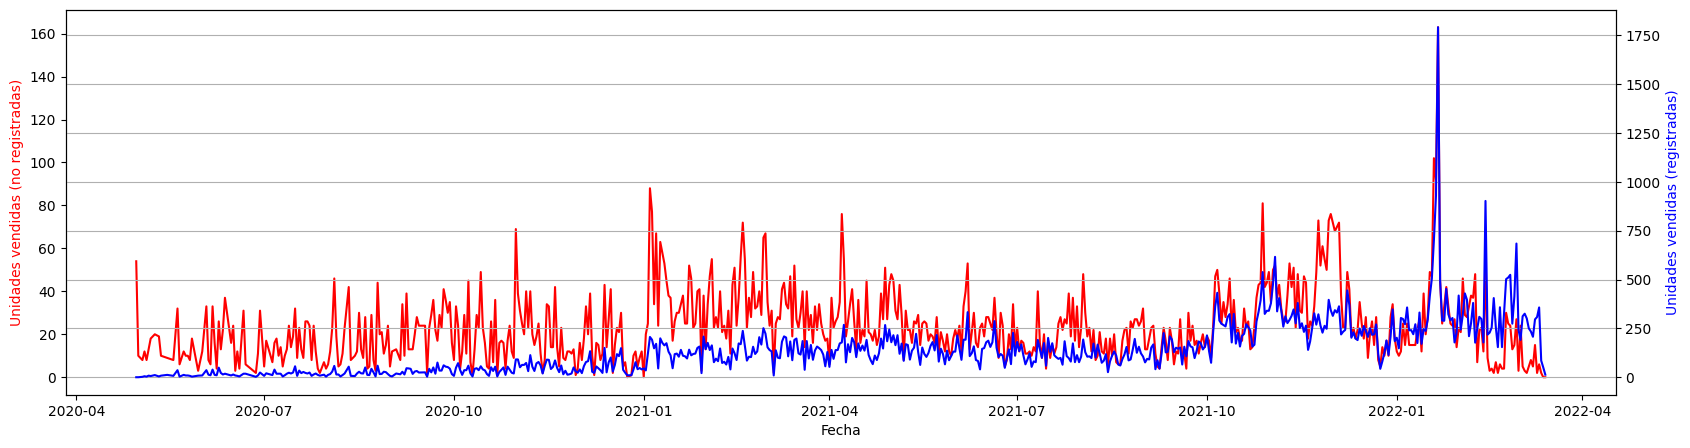

In [86]:
fig, ax1 = plt.subplots(figsize=(20,5))

ax1.plot(df_evolucion_producto_registrado.index, df_evolucion_producto_registrado['no_registrado'], label='No registrado', color='r')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Unidades vendidas (no registradas)', color='r')

ax2 = ax1.twinx()
ax2.plot(df_evolucion_producto_registrado.index, df_evolucion_producto_registrado['registrado'], label='Registrado', color='b')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Unidades vendidas (registradas)', color='b')


plt.grid(visible=True)

Observamos que la forma de las dos curvas son muy semejantes. En la mayoría de tramos responden de manera semejante. Esto puede ser porque hay ciertos productos que no se tienen en el inventario de manera continuada

In [1]:
3==(2+1) and not 4<1

True

In [2]:
type({'Edad':22, 'Profesión':'Estudiante'})

dict